In [17]:
# =============================
# 1. IMPORT LIBRARIES
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.cluster import KMeans

from xgboost import XGBClassifier
import shap
import pickle

In [18]:
# =============================
# 2. LOAD DATA
# =============================
df = pd.read_csv('D:/D drive/Project/ML/Customer-Churn-Project/data/Telco-Customer-Churn.csv')


In [19]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary:\n", df.describe())

Shape: (7043, 21)

Columns:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn           

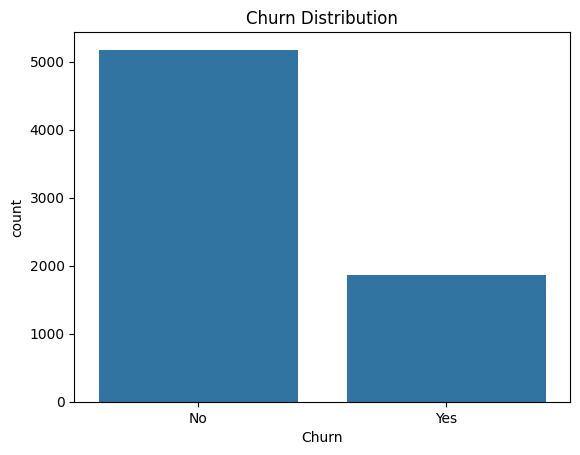

In [20]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

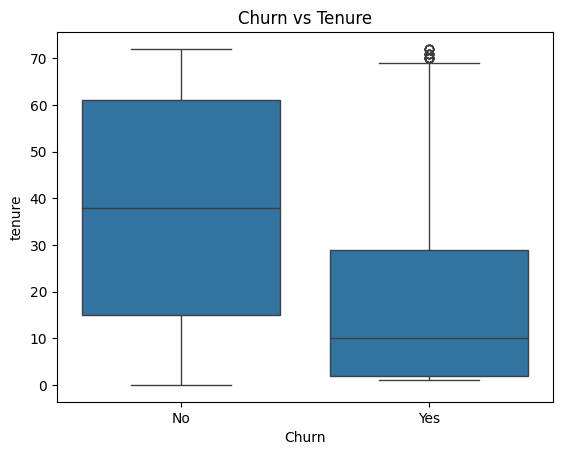

In [21]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Churn vs Tenure")
plt.show()

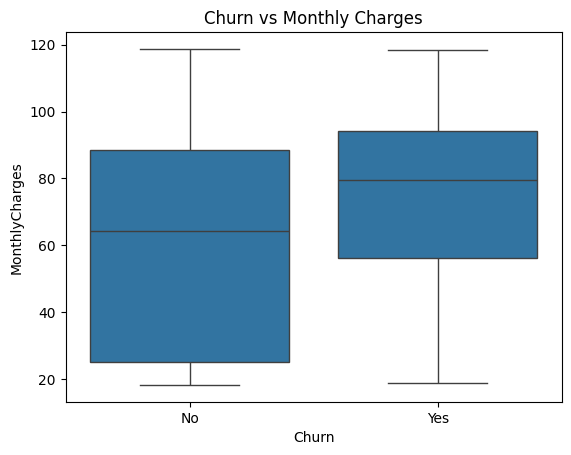

In [22]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Churn vs Monthly Charges")
plt.show()

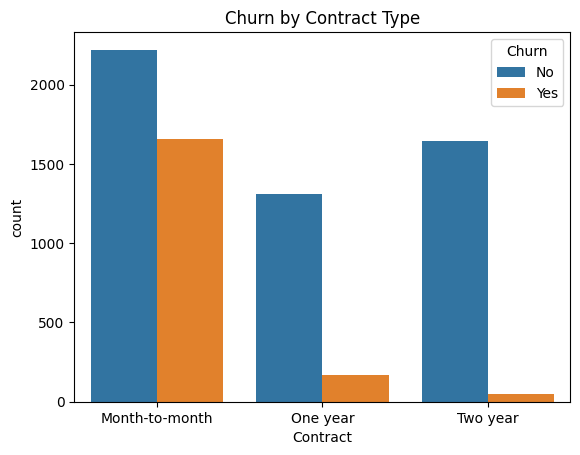

In [23]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

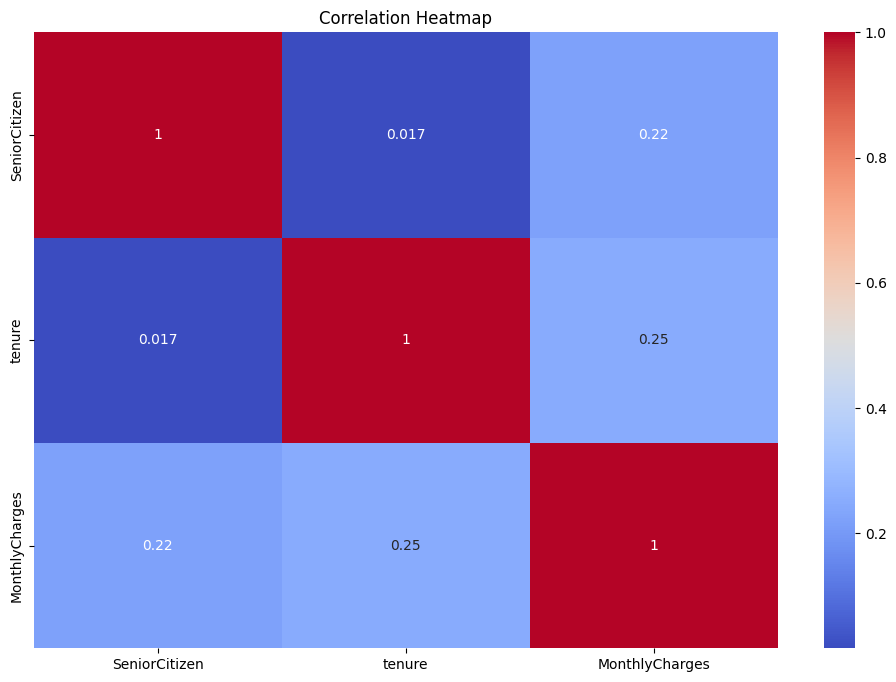

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

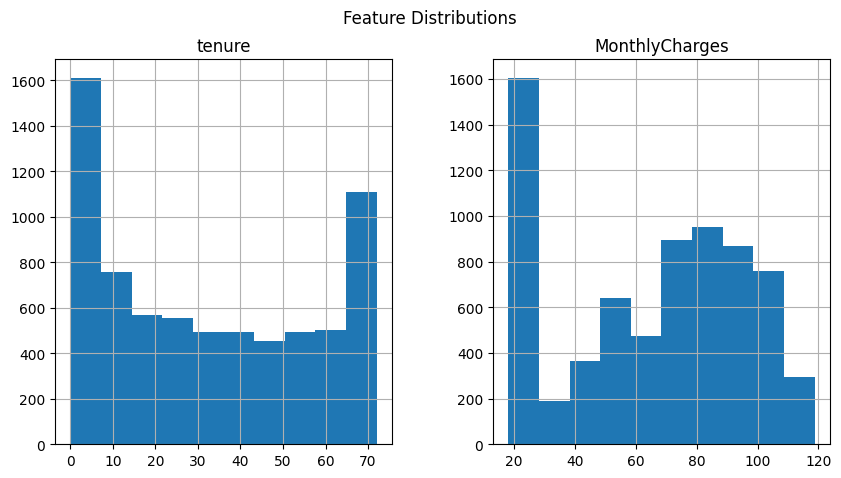

In [25]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(figsize=(10,5))
plt.suptitle("Feature Distributions")
plt.show()

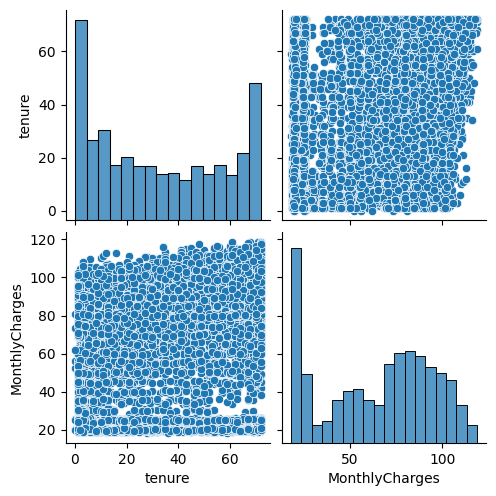

In [26]:
sns.pairplot(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])
plt.show()

In [27]:
# =============================
# 3. DATA PREPROCESSING
# =============================
#df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

C:\Users\anany\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [20:37:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.776303317535545
ROC-AUC: 0.8079239207861089
[[1355  194]
 [ 278  283]]
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1549
           1       0.59      0.50      0.55       561

    accuracy                           0.78      2110
   macro avg       0.71      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110



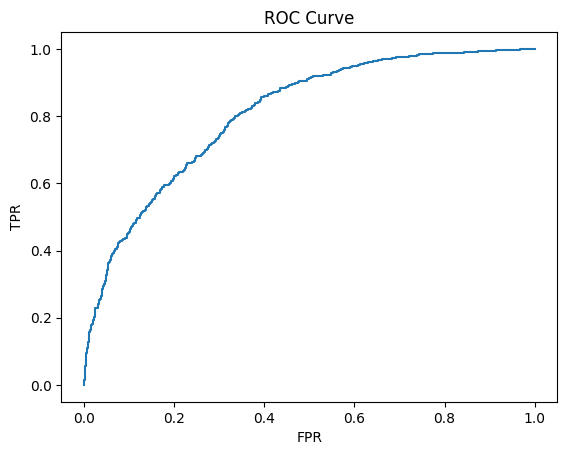

In [28]:
# =============================
# 4. MODEL BUILDING (XGBOOST)
# =============================
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

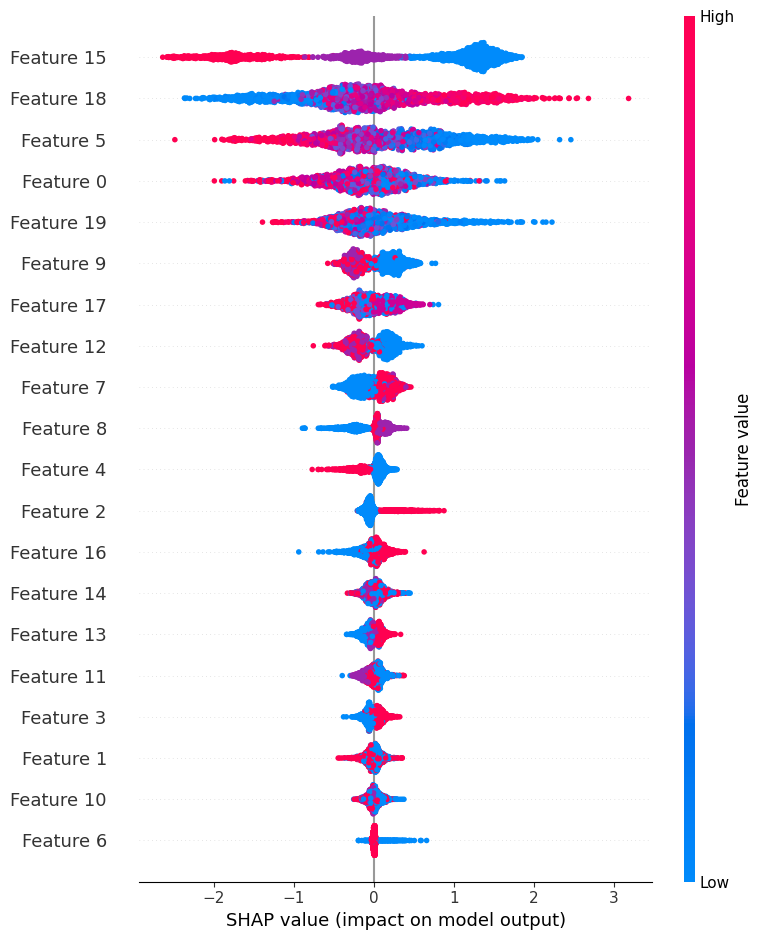

In [29]:
# =============================
# 5. SHAP EXPLAINABILITY
# =============================
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [30]:
# =============================
# 6. CUSTOMER SEGMENTATION
# =============================
kmeans = KMeans(n_clusters=3, random_state=42)
df['Segment'] = kmeans.fit_predict(X_scaled)

In [31]:
# =============================
# 7. RECOMMENDATION SYSTEM
# =============================
def advanced_recommend(features):
    rec = []

    if features['MonthlyCharges'] > 80:
        rec.append("Offer discount")
    if features['Contract'] == 0:
        rec.append("Promote yearly plan")
    if features['tenure'] < 6:
        rec.append("Customer onboarding program")
    if features['InternetService'] == 0:
        rec.append("Upgrade internet service")

    return rec

In [33]:
# =============================
# 8. SAVE MODEL
# =============================
pickle.dump(model, open('D:/D drive/Project/ML/Customer-Churn-Project/model/model.pkl', 'wb'))
pickle.dump(scaler, open('D:/D drive/Project/ML/Customer-Churn-Project/model/scaler.pkl', 'wb'))
pickle.dump(X.columns.tolist(), open('D:/D drive/Project/ML/Customer-Churn-Project/model/columns.pkl', 'wb'))